In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

In [3]:
data={
    'Study_Hours':[2,3,4,5,6,7,8,9],
    'Study_Hours_weeK':[14,21,28,35,42,49,56,63],
    'Attendence':[60,65,70,75,80,85,90,95],
    'Assignment_score':[50,55,58,65,70,74,80,88],
    'Final_marks':[42,48,54,61,67,73,81,89]

}

In [4]:
df=pd.DataFrame(data)
df.to_csv('Study_hours_weekly.csv', index=False)

In [5]:
df

,Study_Hours,Study_Hours_weeK,Attendence,Assignment_score,Final_marks
0,2,14,60,50,42
1,3,21,65,55,48
2,4,28,70,58,54
3,5,35,75,65,61
4,6,42,80,70,67
5,7,49,85,74,73
6,8,56,90,80,81
7,9,63,95,88,89


In [6]:
df1=pd.read_csv('/content/Study_hours_weekly.csv')
df1

,Study_Hours,Study_Hours_weeK,Attendence,Assignment_score,Final_marks
0,2,14,60,50,42
1,3,21,65,55,48
2,4,28,70,58,54
3,5,35,75,65,61
4,6,42,80,70,67
5,7,49,85,74,73
6,8,56,90,80,81
7,9,63,95,88,89


In [7]:
x=df[['Study_Hours','Study_Hours_weeK','Attendence','Assignment_score']]
y=df['Final_marks']

In [8]:
x

,Study_Hours,Study_Hours_weeK,Attendence,Assignment_score
0,2,14,60,50
1,3,21,65,55
2,4,28,70,58
3,5,35,75,65
4,6,42,80,70
5,7,49,85,74
6,8,56,90,80
7,9,63,95,88


In [9]:
y

,Final_marks
0,42
1,48
2,54
3,61
4,67
5,73
6,81
7,89


In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score

In [11]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)#random_state to avoid ranodm number each time the cell is executed

In [12]:
model = LinearRegression()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [13]:
print('Intercept:', model.intercept_)
print('Actual values:',y_test.values)
print('Predicted values:',y_pred)


Intercept: -5.246666666666698
Actual values: [48 73]
Predicted values: [48.28       73.69333333]


In [14]:
coefficient = pd.DataFrame({
    'Features':x.columns,
    'coefficient':model.coef_
})
print(coefficient)

           Features  coefficient
0       Study_Hours     0.050933
1  Study_Hours_weeK     0.356533
2        Attendence     0.254667
3  Assignment_score     0.533333


In [15]:
print('Mean absolute error:', mean_absolute_error(y_test,y_pred))
print('Mean Square Error:', mean_squared_error(y_test,y_pred))
print('Root mean square error:', np.sqrt(mean_squared_error(y_test, y_pred)))
print('R2_ score: ', r2_score(y_test,y_pred))

Mean absolute error: 0.4866666666666717
Mean Square Error: 0.27955555555556205
Root mean square error: 0.5287301349039621
R2_ score:  0.9982108444444444


In [16]:
new_student = pd.DataFrame({
    'Study_Hours':[6],
    'Study_Hours_weeK':[42],
    'Attendence':[82],
    'Assignment_score':[72]
})



In [17]:
test=model.predict(new_student)
print(test[0])

69.31600000000002


Text(0.5, 1.0, 'Actual vs Predicted Marks')

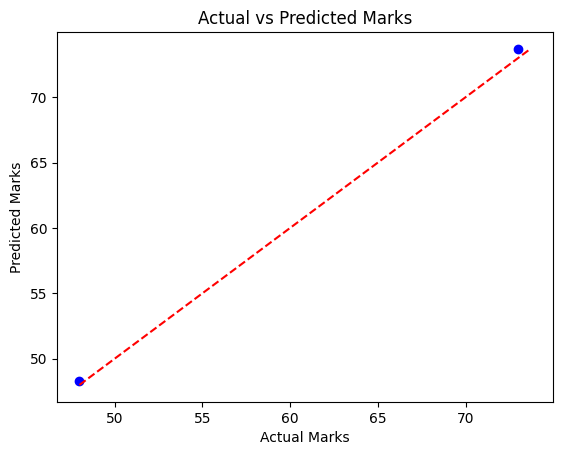

In [18]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred,color='blue')
minimum=min(y_test.min(), y_pred.min())
maximum=max(y_test.max(), y_pred.max())

plt.plot(
    [minimum,maximum],
     [minimum,maximum],
    color='red',
    linestyle='--'
    )
plt.xlabel('Actual Marks')
plt.ylabel('Predicted Marks')
plt.title('Actual vs Predicted Marks')

In [19]:
df.corr()

,Study_Hours,Study_Hours_weeK,Attendence,Assignment_score,Final_marks
Study_Hours,1.000000,1.000000,1.000000,0.995526,0.998607
Study_Hours_weeK,1.000000,1.000000,1.000000,0.995526,0.998607
Attendence,1.000000,1.000000,1.000000,0.995526,0.998607
Assignment_score,0.995526,0.995526,0.995526,1.000000,0.998481
Final_marks,0.998607,0.998607,0.998607,0.998481,1.000000
